In [1]:
import pandas as pd
import numpy as np

customer_features = pd.read_csv(
    "../exports/processed_data/customer_features.csv"
)

customer_features.head()

,customer_id,total_revenue,avg_order_value_x,order_count,customer_name,email,phone,address,area,pincode,registration_date,customer_segment,total_orders,avg_order_value_y,revenue_per_order,value_score
0,31813,5726.04,2863.020000,2,Indrajit Pau,wakeetasehgal@example.com,911785834174,"66, Vora Chowk\nMaheshtala 376030",Sultan Pur Majra,666762,2024-04-10,Regular,18,1230.75,2863.020000,11452.08
1,61020,7844.90,2614.966667,3,Onkar Suresh,rudradeshpande@example.com,918421031341,"88/40, Bora Zila, Phusro-161515",Kurnool,345635,2024-07-27,New,19,1703.16,2614.966667,23534.70
2,119099,14768.77,3692.192500,4,Zansi Parsa,neha08@example.com,912032907631,"H.No. 40, Gopal Ganj, Bidar 854350",Kavali,692517,2023-08-01,Inactive,20,637.35,3692.192500,59075.08
3,188838,5182.04,2591.020000,2,Idika Basu,deepakhanna@example.com,914955579642,"67, Karan Chowk\nKatihar 496332",Madanapalle,566155,2024-07-16,Inactive,12,799.11,2591.020000,10364.08
4,191616,4089.96,2044.980000,2,Brijesh Tata,yadavipatla@example.org,918144382068,"19/151, Bera Nagar, Surendranagar Dudhrej-068367",Pallavaram,587079,2023-04-27,Regular,4,1053.70,2044.980000,8179.92


In [3]:
customer_features[
    [
        "avg_order_value_x",
        "avg_order_value_y"
    ]
].head()

,avg_order_value_x,avg_order_value_y
0,2863.020000,1230.75
1,2614.966667,1703.16
2,3692.192500,637.35
3,2591.020000,799.11
4,2044.980000,1053.70


In [7]:
customer_features.rename(
    columns={
        "avg_order_value_x":"calculated_aov",
        "avg_order_value_y":"customer_aov"
    },
    inplace=True
)

In [5]:
features = customer_features[
    [
        "total_revenue",
        "calculated_aov",
        "order_count",
        "revenue_per_order",
        "value_score"
    ]
]

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(
    features
)

In [9]:
from sklearn.cluster import KMeans

inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(
        scaled_features
    )

    inertia.append(
        model.inertia_
    )

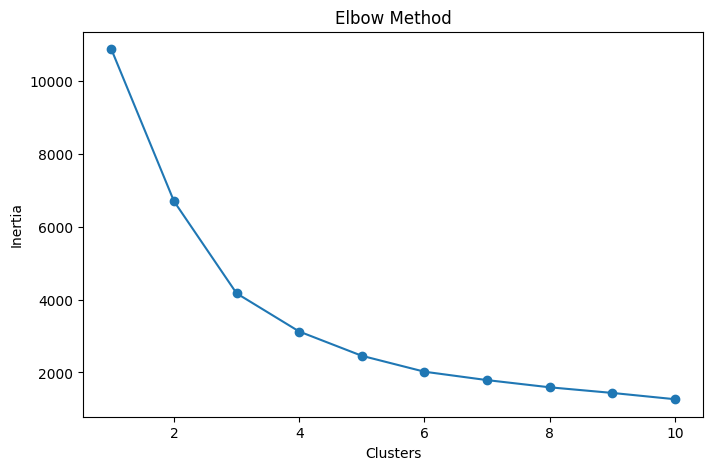

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    inertia,
    marker="o"
)

plt.xlabel("Clusters")
plt.ylabel("Inertia")

plt.title(
    "Elbow Method"
)

plt.show()

In [11]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

customer_features["cluster"] = (
    kmeans.fit_predict(
        scaled_features
    )
)

In [13]:
cluster_summary = (
    customer_features.groupby("cluster")
    [
        [
            "total_revenue",
            "calculated_aov",
            "order_count"
        ]
    ]
    .mean()
)

cluster_summary

,total_revenue,calculated_aov,order_count
cluster,,,
0,5872.224191,2142.505293,2.804178
1,4745.974069,3442.591178,1.387580
2,11529.060769,2669.541589,4.465201
3,1722.794730,1178.530617,1.478979


In [17]:
cluster_labels = {
    0: "Regular Customers",
    1: "Premium Shoppers",
    2: "High-Value Loyal Customers",
    3: "Occasional Customers"
}

customer_features["customer_segment_ml"] = (
    customer_features["cluster"]
    .map(cluster_labels)
)

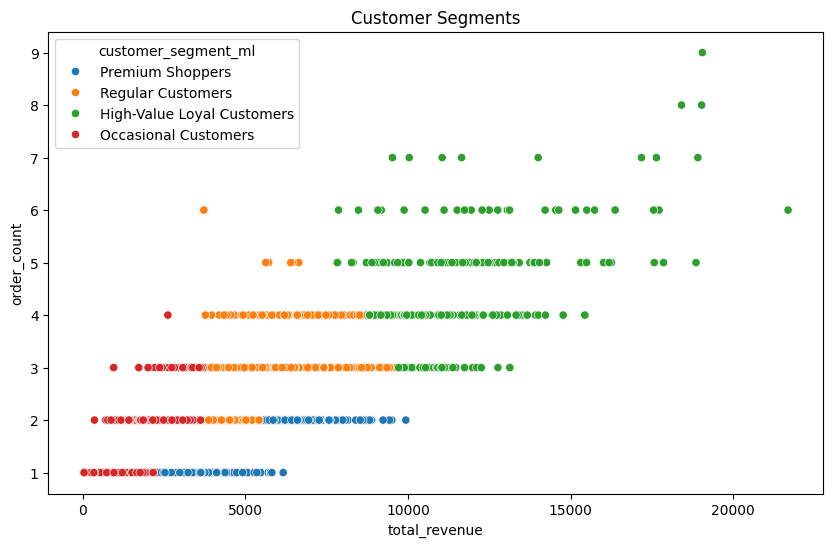

In [18]:
import seaborn as sns

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=customer_features,
    x="total_revenue",
    y="order_count",
    hue="customer_segment_ml"
)

plt.title("Customer Segments")

plt.show()

In [19]:
segment_summary = (
    customer_features
    .groupby("customer_segment_ml")
    .agg({
        "customer_id":"count",
        "total_revenue":"mean",
        "calculated_aov":"mean",
        "order_count":"mean"
    })
    .reset_index()
)

In [20]:
customer_features.to_csv(
    "../exports/segmentation_output/customer_segments.csv",
    index=False
)

segment_summary.to_csv(
    "../exports/segmentation_output/customer_segment_summary.csv",
    index=False
)

In [21]:
print("""
Customer Segmentation Insights

• High-Value Loyal Customers generate the highest revenue and order frequency.
• Premium Shoppers place fewer orders but spend significantly more per transaction.
• Regular Customers form the stable core customer base.
• Occasional Customers contribute the least revenue and may require re-engagement campaigns.
""")


Customer Segmentation Insights

• High-Value Loyal Customers generate the highest revenue and order frequency.
• Premium Shoppers place fewer orders but spend significantly more per transaction.
• Regular Customers form the stable core customer base.
• Occasional Customers contribute the least revenue and may require re-engagement campaigns.

